# Persistent Homology & Betti Numbers
## Algebraic invariants of a filtration

Persistent homology is the central computational tool of TDA. Given a filtration of simplicial complexes, it tracks the evolution of homological features across scales and encodes them as a collection of birth-death pairs.

**Betti numbers** $\beta_k$ are the rank of the $k$-th homology group — they count the number of independent $k$-dimensional features:

- $\beta_0$ — connected components
- $\beta_1$ — loops / 1-dimensional holes  
- $\beta_2$ — voids / 2-dimensional cavities

Persistent homology generalizes this by tracking how $\beta_k$ changes across the filtration.

## Libraries

Three major TDA libraries are used in this notebook, each with different design philosophy:

- **Ripser** — minimalist, extremely fast Vietoris-Rips persistent homology
- **GUDHI** — mathematically rigorous, most complete TDA library, developed by INRIA
- **Giotto-TDA** — scikit-learn compatible, designed for machine learning pipelines

We compute persistent homology on the same point cloud with all three and compare results and API design.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
from itertools import combinations

## Point Cloud

We use a noisy circle $S^1$ as our test case — its homology $H_0 = \mathbb{Z}$, $H_1 = \mathbb{Z}$ provides a clean ground truth to verify each library's output.

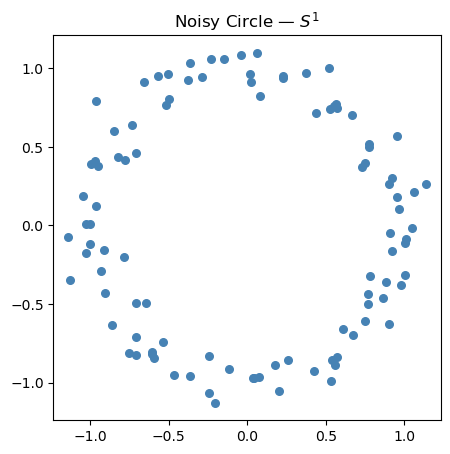

In [12]:
# Noisy circle — ground truth: H0 = 1, H1 = 1
np.random.seed(42)
theta = np.linspace(0, 2 * np.pi, 100)
X = np.column_stack([np.cos(theta), np.sin(theta)])
X += np.random.normal(0, 0.1, X.shape)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c='steelblue', s=30)
plt.title("Noisy Circle — $S^1$")
plt.axis('equal')
plt.show()

## 1. Ripser

Ripser computes persistent homology via the Vietoris-Rips filtration. It is the fastest available implementation, based on the algorithm by Ulrich Bauer (2021).

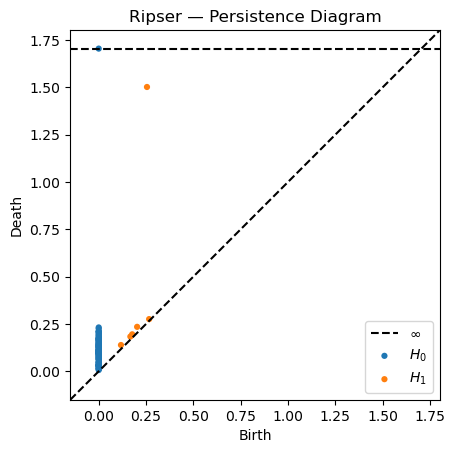

In [13]:
# Persistent homology with Ripser
diagrams_ripser = ripser(X)['dgms']
plot_diagrams(diagrams_ripser, show=True, title="Ripser — Persistence Diagram")

## 2. GUDHI

GUDHI constructs the Vietoris-Rips complex explicitly before computing persistent homology. It provides more control over the construction and access to the full simplicial complex.

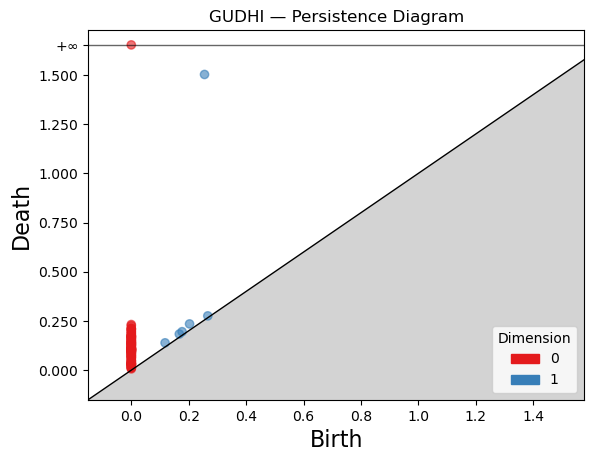

In [14]:
import gudhi
import warnings

# Suppress LaTeX warning
warnings.filterwarnings('ignore')

# Construct Vietoris-Rips complex
rips_complex = gudhi.RipsComplex(points=X, max_edge_length=2.0)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=2)

# Compute persistent homology
simplex_tree.compute_persistence()

# Plot
gudhi.plot_persistence_diagram(simplex_tree.persistence())
plt.title("GUDHI — Persistence Diagram")
plt.show()

## 3. Giotto-TDA

Giotto-TDA wraps persistent homology in a scikit-learn compatible transformer — making it trivially composable into machine learning pipelines. This is its key advantage over Ripser and GUDHI.

In [15]:
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram

# Giotto expects input shape (n_samples, n_points, n_dimensions)
X_gtda = X.reshape(1, *X.shape)

# Compute persistent homology
VR = VietorisRipsPersistence(homology_dimensions=[0, 1])
diagrams_gtda = VR.fit_transform(X_gtda)

# Plot
plot_diagram(diagrams_gtda[0])

## Comparison

| Library | API Style | Speed | Control | Best For |
|---------|-----------|-------|---------|----------|
| Ripser | Minimal | Fastest | Low | Quick computations |
| GUDHI | Explicit | Fast | High | Complex constructions |
| Giotto-TDA | Sklearn | Moderate | Medium | ML pipelines |

All three recover the correct homology of $S^1$:
- **H0** — one persistent connected component
- **H1** — one persistent loop generator

### When Ripser dominates
- Large point clouds where speed is critical
- Exploratory analysis — fast iteration over parameters
- When only Vietoris-Rips is needed and no further complex manipulation is required

### When GUDHI dominates
- Need access to the full simplicial complex structure
- Working with Alpha complexes or Čech complexes — not just Vietoris-Rips
- Rigorous mathematical work where explicit control over the construction matters
- Computing topological invariants beyond persistence diagrams

### When Giotto-TDA dominates
- Building end-to-end ML pipelines with sklearn
- Cross-validation over topological features
- Combining TDA with classifiers or regressors in a single pipeline
- Financial applications where TDA features feed into predictive models

## Betti Numbers Across the Filtration

The $k$-th Betti number $\beta_k(\varepsilon)$ counts the number of independent $k$-dimensional features alive at scale $\varepsilon$. Tracking $\beta_k$ across the filtration gives a functional summary of the topology at every scale.

$$\beta_k(\varepsilon) = \#\{(b,d) \in \text{dgm}_k : b \leq \varepsilon < d\}$$

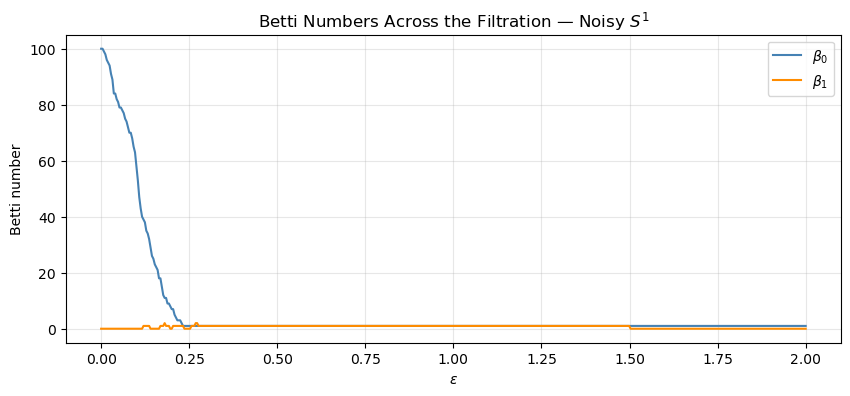

In [16]:
# Compute Betti numbers across filtration using Ripser
diagrams = ripser(X)['dgms']

# Define epsilon range
epsilons = np.linspace(0, 2, 500)

# Compute beta_0 and beta_1 at each epsilon
def betti(diagram, epsilon):
    return np.sum((diagram[:, 0] <= epsilon) & (diagram[:, 1] > epsilon))

beta_0 = [betti(diagrams[0], e) for e in epsilons]
beta_1 = [betti(diagrams[1], e) for e in epsilons]

# Plot
plt.figure(figsize=(10, 4))
plt.plot(epsilons, beta_0, label='$\\beta_0$', color='steelblue')
plt.plot(epsilons, beta_1, label='$\\beta_1$', color='darkorange')
plt.xlabel('$\\varepsilon$')
plt.ylabel('Betti number')
plt.title('Betti Numbers Across the Filtration — Noisy $S^1$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Observations

- $\beta_0$ starts at 100 — each point is its own connected component — and monotonically decreases to 1 as points merge into a single component
- $\beta_1$ rises from 0 to 1 as the loop forms, then drops back to 0 as the complex fills in at large $\varepsilon$

The interval where $\beta_1 = 1$ corresponds precisely to the persistent H1 generator in the persistence diagram — this is the topological signature of $S^1$.

Betti curves provide a functional, vectorizable summary of topology across scales — directly usable as features in machine learning models.